<h1 style='color: blue; font-size: 34px; font-weight: bold;'> Projeto Proposto — Forecasting da Temperatura Média Diária de Delhi
</h1>

# <font color='red' style='font-size: 40px;'> Problemática </font>
<hr style='border: 2px solid red;'>

<p style='font-size: 18px; line-height: 2; margin: 0px 0px; text-align: justify; text-indent: 0px;'>
<i>Este projeto tem o intuito de estudar diferentes classes de Modelos de Séries Temporais para prever a temperatura média diária de Delhi, na Índia. O problema será tratado como uma previsão de curto prazo: ao final do dia D, deseja-se estimar a temperatura média do dia D+1.</i>
</p>

<p style='font-size: 18px; line-height: 2; margin: 15px 0px; text-align: justify; text-indent: 0px;'>
<i>Serão comparados modelos estatísticos, algoritmos de Machine Learning e uma Rede Neural Recorrente: ARIMA, SARIMA, Random Forest, LightGBM e LSTM. Como referência, também serão utilizadas duas previsões simples — a persistência D-1 e o sazonal ingênuo D-7.</i>
</p>

<div style='background-color:#eef7ff; border-left:6px solid #1f77b4; padding:14px; font-size:17px; line-height:1.7;'>
<b>Pergunta principal:</b> modelos mais complexos conseguem prever D+1 melhor e de forma consistente do que simplesmente assumir que a temperatura de amanhã será igual à temperatura observada hoje?
</div>

# <font color='red' style='font-size: 40px;'> Bibliotecas Utilizadas </font>
<hr style='border: 2px solid red;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
As bibliotecas são utilizadas para manipulação dos dados, visualização, testes estatísticos, decomposição de séries temporais e treinamento dos modelos. A comparação será orientada pelo desenho temporal do experimento: todos os modelos devem prever as mesmas datas e utilizar apenas informações disponíveis no instante da previsão.
</p>

In [ ]:
import os
os.environ['TEMPORARILY_DISABLE_PROTOBUF_VERSION_CHECK'] = 'true'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['LOKY_MAX_CPU_COUNT'] = '8'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

from src.functions import (
    FEATURES, FOLDS, SEED, TARGET, ExperimentResult,
    block_bootstrap_comparison, error_metrics, interpret_tree_models,
    load_official_splits, lstm_forecast, make_features, model_catalog,
    rolling_statistical_forecast, run_experiment, select_statistical_orders,
    set_seed, stationarity_row,
)


# <font color='red' style='font-size: 40px;'> 1) Leitura do Dataset </font>
<hr style='border: 2px solid red;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
O conjunto público é disponibilizado em dois arquivos: um período de desenvolvimento e um teste oficial. A data de 01/01/2017 aparece nos dois arquivos com valores diferentes. Optou-se por manter a observação pertencente ao teste e encerrar o desenvolvimento em 31/12/2016.
</p>

<div style='background-color:#fff8e1; border-left:6px solid #f4b400; padding:12px; font-size:17px;'>
O teste de 2017 será reservado até a etapa final. Ele não será utilizado para escolher features, ordens, hiperparâmetros ou número de épocas.
</div>

In [4]:
development, official_test = load_official_splits('data')

split_summary = pd.DataFrame({
    'amostra': ['Desenvolvimento', 'Teste oficial'],
    'início': [development.date.min(), official_test.date.min()],
    'fim': [development.date.max(), official_test.date.max()],
    'observações': [len(development), len(official_test)],
})
display(split_summary)
display(development.head())

,amostra,início,fim,observações
0,Desenvolvimento,2013-01-01,2016-12-31,1461
1,Teste oficial,2017-01-01,2017-04-24,114


,date,meantemp,humidity,wind_speed,meanpressure,official_split
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,development
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,development
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,development
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,development
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,development


# <font color='green' style='font-size: 30px;'> 1.1) Descrição das Variáveis </font>
<hr style='border: 2px solid green;'>

### 1.1.1) Cases

1. **date:** Data da observação

2. **meantemp:** Temperatura média diária — variável que será prevista

3. **humidity:** Umidade média diária

4. **wind_speed:** Velocidade média diária do vento

5. **meanpressure:** Pressão atmosférica média diária

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Umidade, vento e pressão serão estudados na análise exploratória. Entretanto, seus valores contemporâneos de D+1 não entram no benchmark principal, pois ainda não seriam conhecidos no instante da previsão. Eles poderiam ser incorporados em outro cenário caso existissem previsões meteorológicas externas dessas variáveis.
</p>

In [5]:
display(development.drop(columns='official_split').describe().T.round(2))
print('Valores ausentes no desenvolvimento:')
display(development.isna().sum().to_frame('ausentes'))

,count,mean,min,25%,50%,75%,max,std
date,1461,2015-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2016-12-31 00:00:00,NaN
meantemp,1461.0,25.506127,6.0,18.857143,27.714286,31.3125,38.714286,7.339416
humidity,1461.0,60.744851,13.428571,50.375,62.625,72.125,98.0,16.743928
wind_speed,1461.0,6.806865,0.0,3.475,6.25,9.25,42.22,4.559688
meanpressure,1461.0,1011.101197,-3.041667,1001.571429,1008.555556,1014.9375,7679.333333,180.293335


Valores ausentes no desenvolvimento:


,ausentes
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0
official_split,0


# <font color='red' style='font-size: 40px;'> 2) Análise Exploratória </font>
<hr style='border: 2px solid red;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
A análise exploratória será realizada somente no período de desenvolvimento. O objetivo é investigar distribuições, valores extremos, tendências, sazonalidades, estacionaridade e persistência temporal antes da construção dos modelos.
</p>

# <font color='green' style='font-size: 30px;'> 2.1) Como é a distribuição das variáveis? </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Para cada variável serão avaliados histograma, boxplot e QQ Plot. Essas visualizações respondem perguntas diferentes: o histograma mostra a forma da distribuição, o boxplot evidencia assimetria e valores extremos, enquanto o QQ Plot compara os quantis observados com os de uma distribuição Normal.
</p>

> 1. Valores extremos em séries meteorológicas não devem ser removidos automaticamente, pois podem representar eventos reais.
>
> 2. A pressão atmosférica possui observações muito afastadas da faixa principal, sugerindo possíveis erros de medição.
>
> 3. Como o benchmark será univariado em relação ao alvo, esses valores de pressão não interferem diretamente nos modelos de previsão.

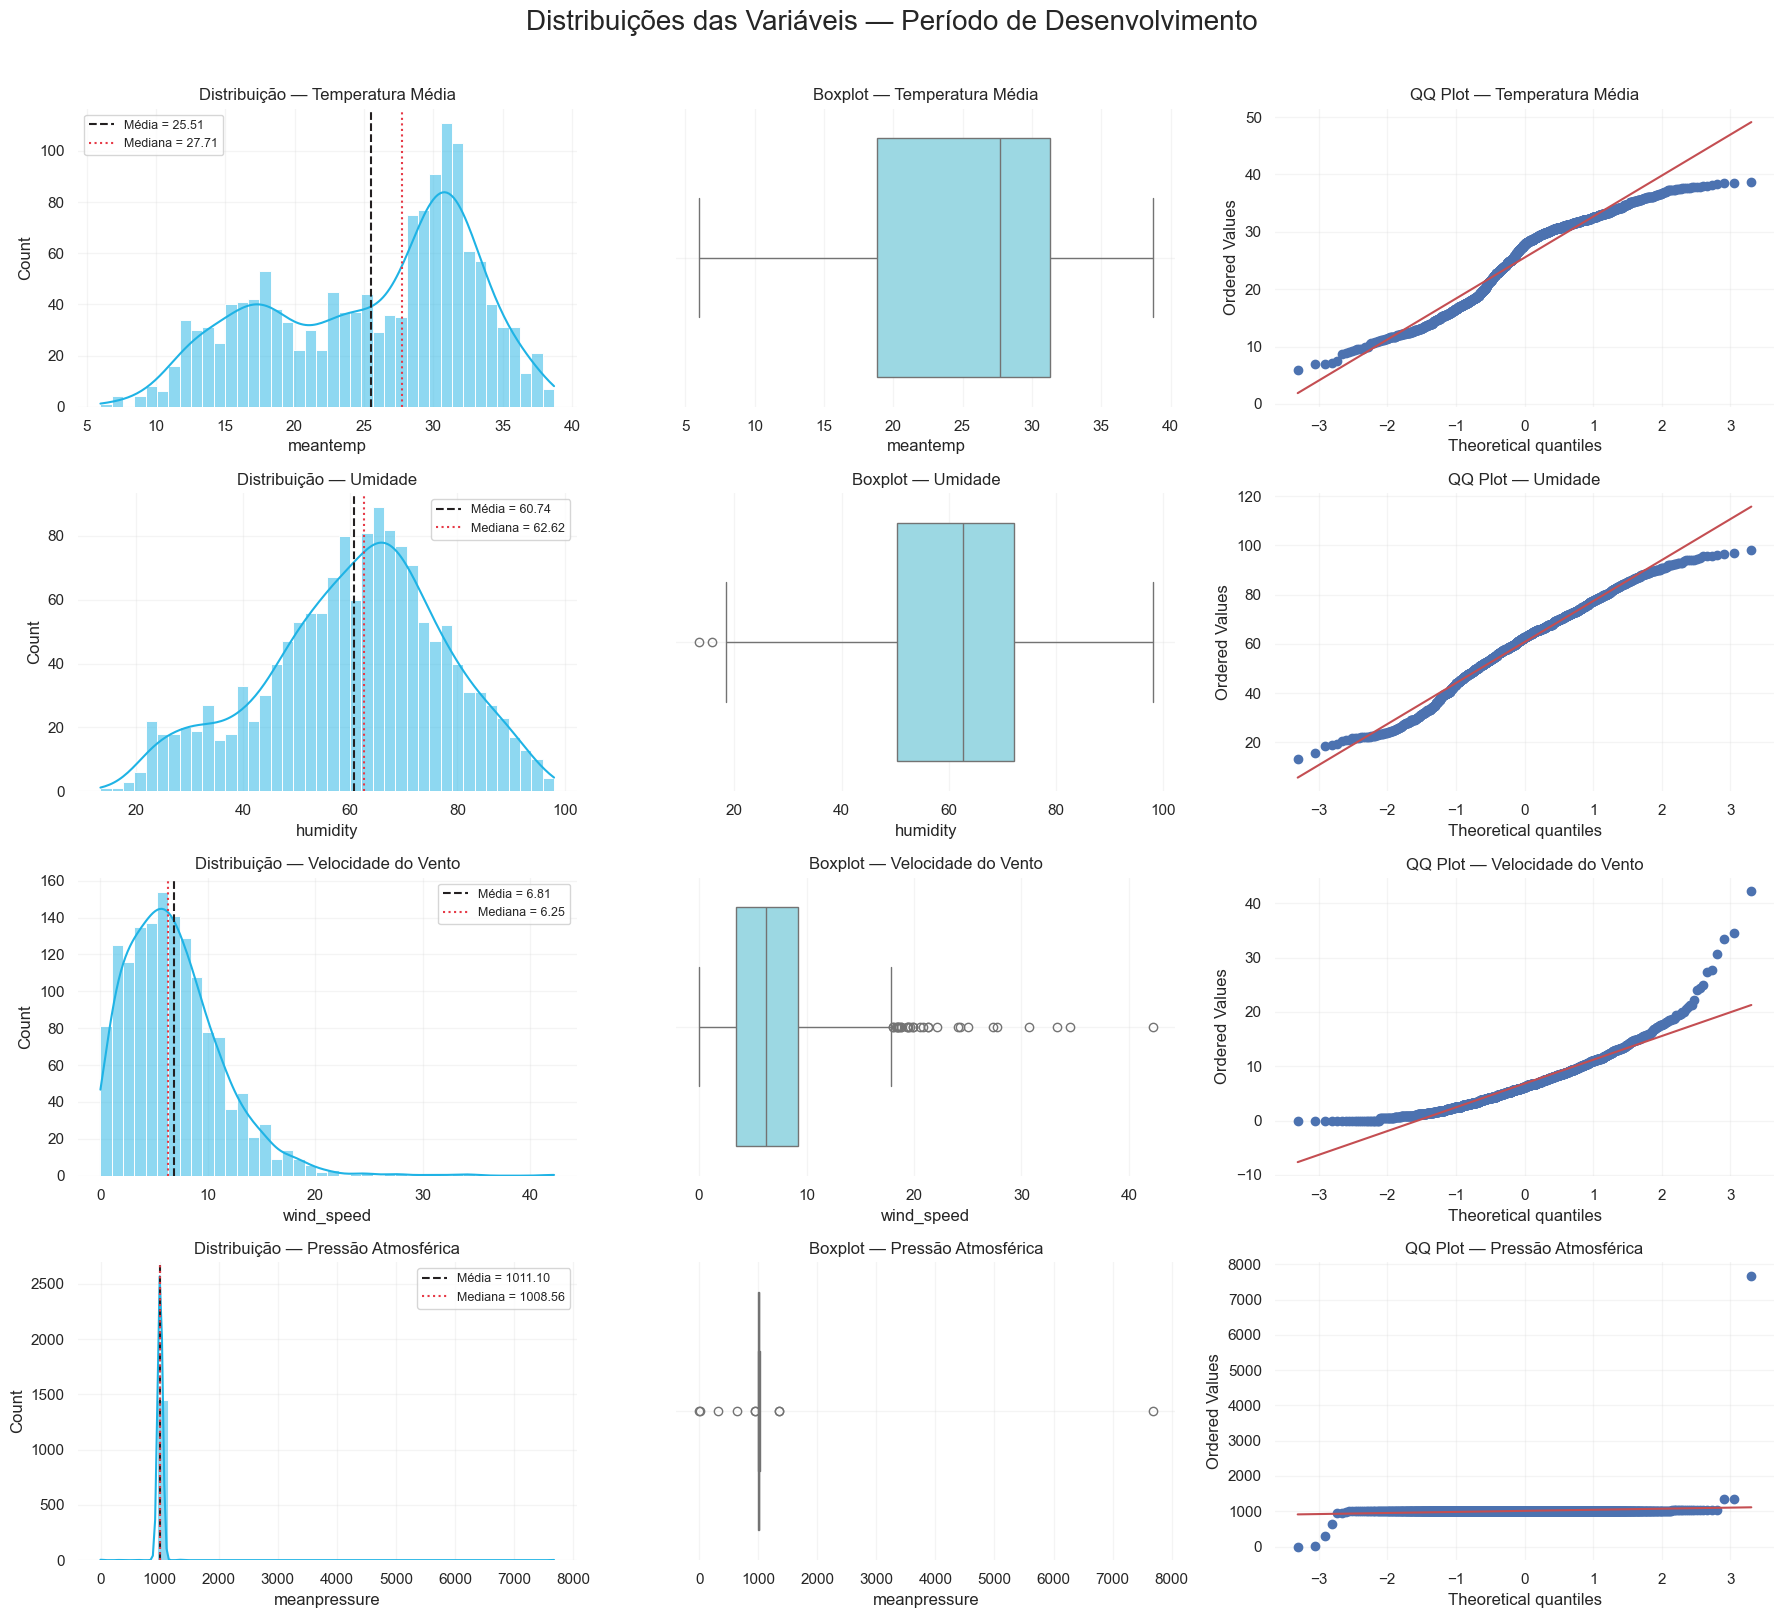

In [6]:
variables = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
titles = ['Temperatura Média', 'Umidade', 'Velocidade do Vento', 'Pressão Atmosférica']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for row, (variable, title) in enumerate(zip(variables, titles)):
    values = development[variable].dropna()
    sns.histplot(values, bins=40, kde=True, color='#1FB3E5', ax=axes[row, 0])
    axes[row, 0].axvline(values.mean(), color='#231F20', linestyle='--', label=f'Média = {values.mean():.2f}')
    axes[row, 0].axvline(values.median(), color='#E63946', linestyle=':', label=f'Mediana = {values.median():.2f}')
    axes[row, 0].set_title(f'Distribuição — {title}')
    axes[row, 0].legend(fontsize=9)

    sns.boxplot(x=values, color='#90E0EF', ax=axes[row, 1])
    axes[row, 1].set_title(f'Boxplot — {title}')

    stats.probplot(values, dist='norm', plot=axes[row, 2])
    axes[row, 2].set_title(f'QQ Plot — {title}')

    for ax in axes[row]:
        ax.grid(alpha=0.20)
        ax.set_frame_on(False)

plt.suptitle('Distribuições das Variáveis — Período de Desenvolvimento', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

# <font color='green' style='font-size: 30px;'> 2.2) Como as variáveis se comportam ao longo do tempo? </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
As séries serão apresentadas junto com uma média móvel de 30 dias. A observação diária permite enxergar a variabilidade de curto prazo, enquanto a média móvel ajuda a visualizar movimentos mais lentos e ciclos sazonais.
</p>

> 1. Temperatura e umidade apresentam ciclos anuais bem definidos.
>
> 2. A pressão atmosférica se movimenta de forma aproximadamente inversa à temperatura em parte do ano.
>
> 3. A velocidade do vento possui comportamento mais irregular e uma componente sazonal menos evidente.

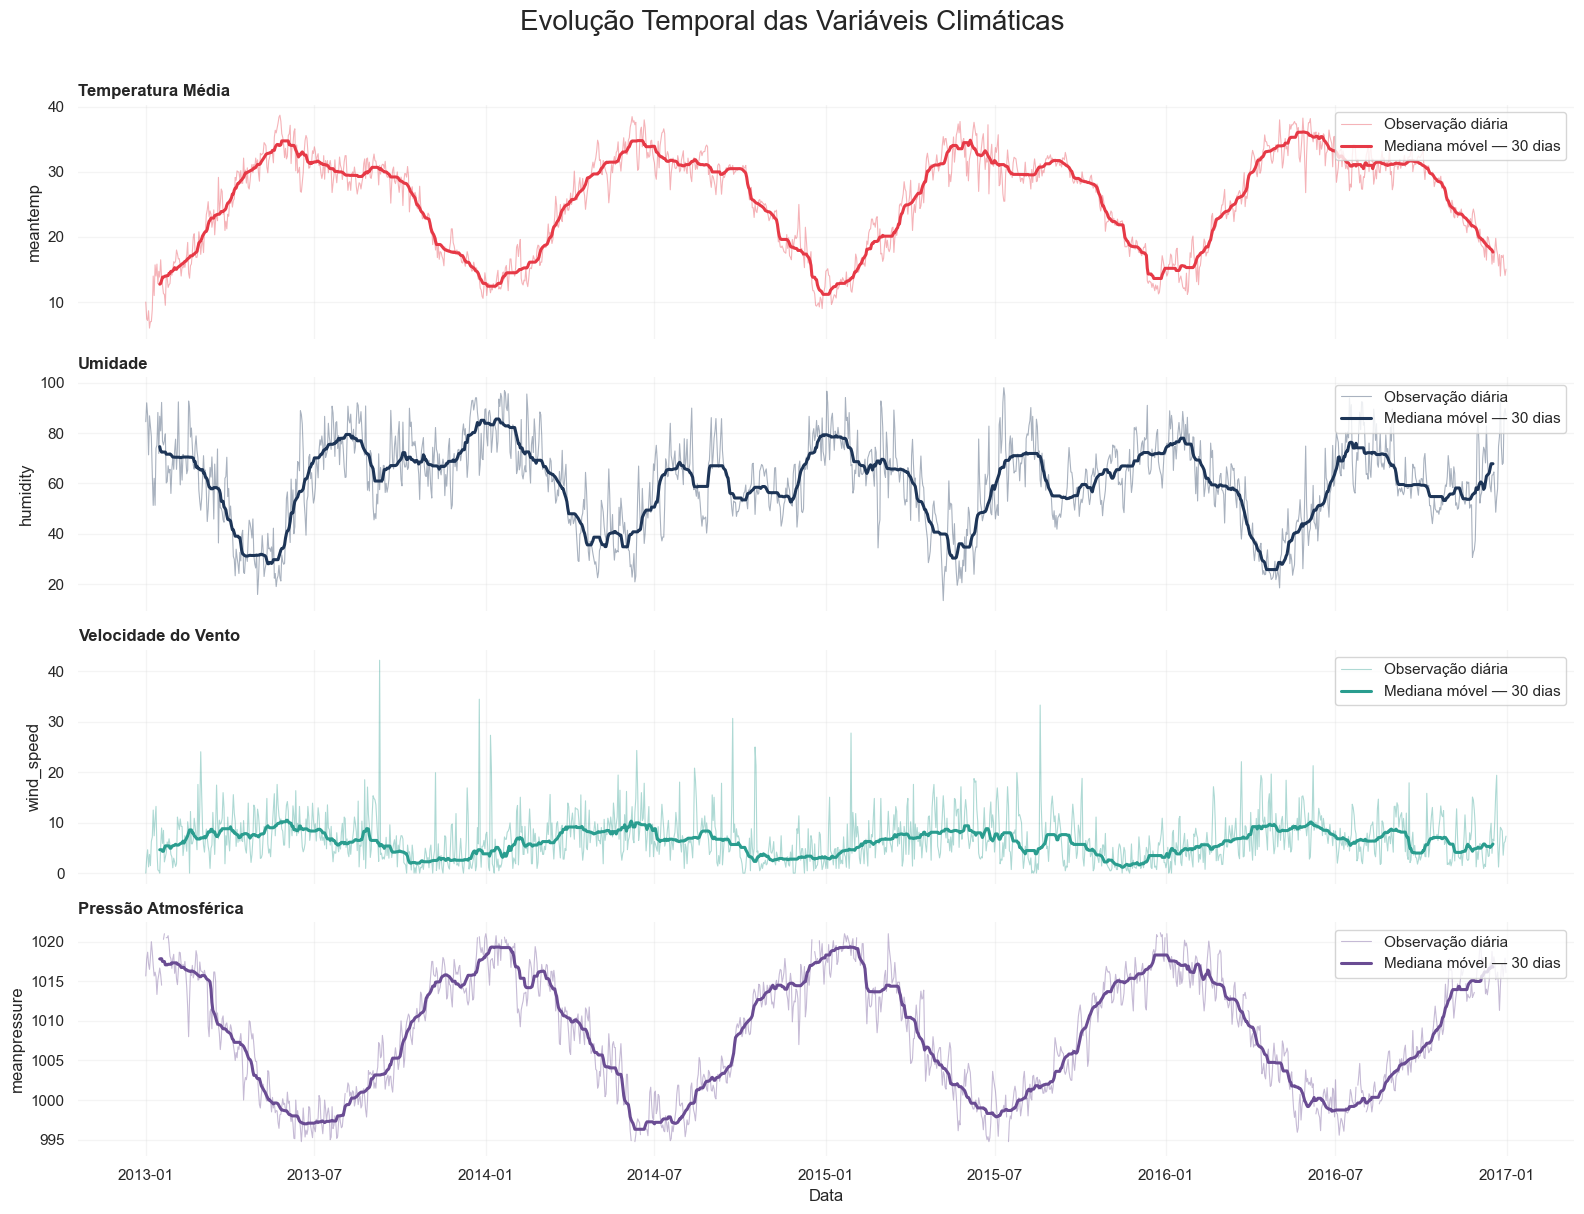

In [7]:
variables = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
titles = ['Temperatura Média', 'Umidade', 'Velocidade do Vento', 'Pressão Atmosférica']
colors = ['#E63946', '#1D3557', '#2A9D8F', '#6A4C93']

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
for variable, title, color, ax in zip(variables, titles, colors, axes):
    series = development.set_index('date')[variable]
    if variable == 'meanpressure':
        lower, upper = series.quantile([0.01, 0.99])
        visual = series.where(series.between(lower, upper))
    else:
        visual = series
    ax.plot(visual.index, visual, color=color, alpha=0.38, linewidth=0.8, label='Observação diária')
    ax.plot(series.index, series.rolling(30, center=True).median(), color=color, linewidth=2.2, label='Mediana móvel — 30 dias')
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_ylabel(variable)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.20)
    ax.set_frame_on(False)

axes[-1].set_xlabel('Data')
plt.suptitle('Evolução Temporal das Variáveis Climáticas', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

# <font color='green' style='font-size: 30px;'> 2.3) Como se comportam as componentes temporais da série histórica? </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Será utilizada uma decomposição aditiva com período anual de 365 dias. Nesse tipo de decomposição, a série é representada pela soma de tendência, sazonalidade e resíduo:
</p>

## $$Y_t = T_t + S_t + R_t$$

| Componente | Interpretação |
|---|---|
| Tendência ($T_t$) | Movimento de longo prazo da série |
| Sazonalidade ($S_t$) | Padrão que se repete em intervalos regulares |
| Resíduo ($R_t$) | Variação não explicada pelas demais componentes |

> A decomposição será utilizada como ferramenta descritiva. Ela ajuda a compreender a série, mas não determina automaticamente a ordem de um ARIMA ou SARIMA.

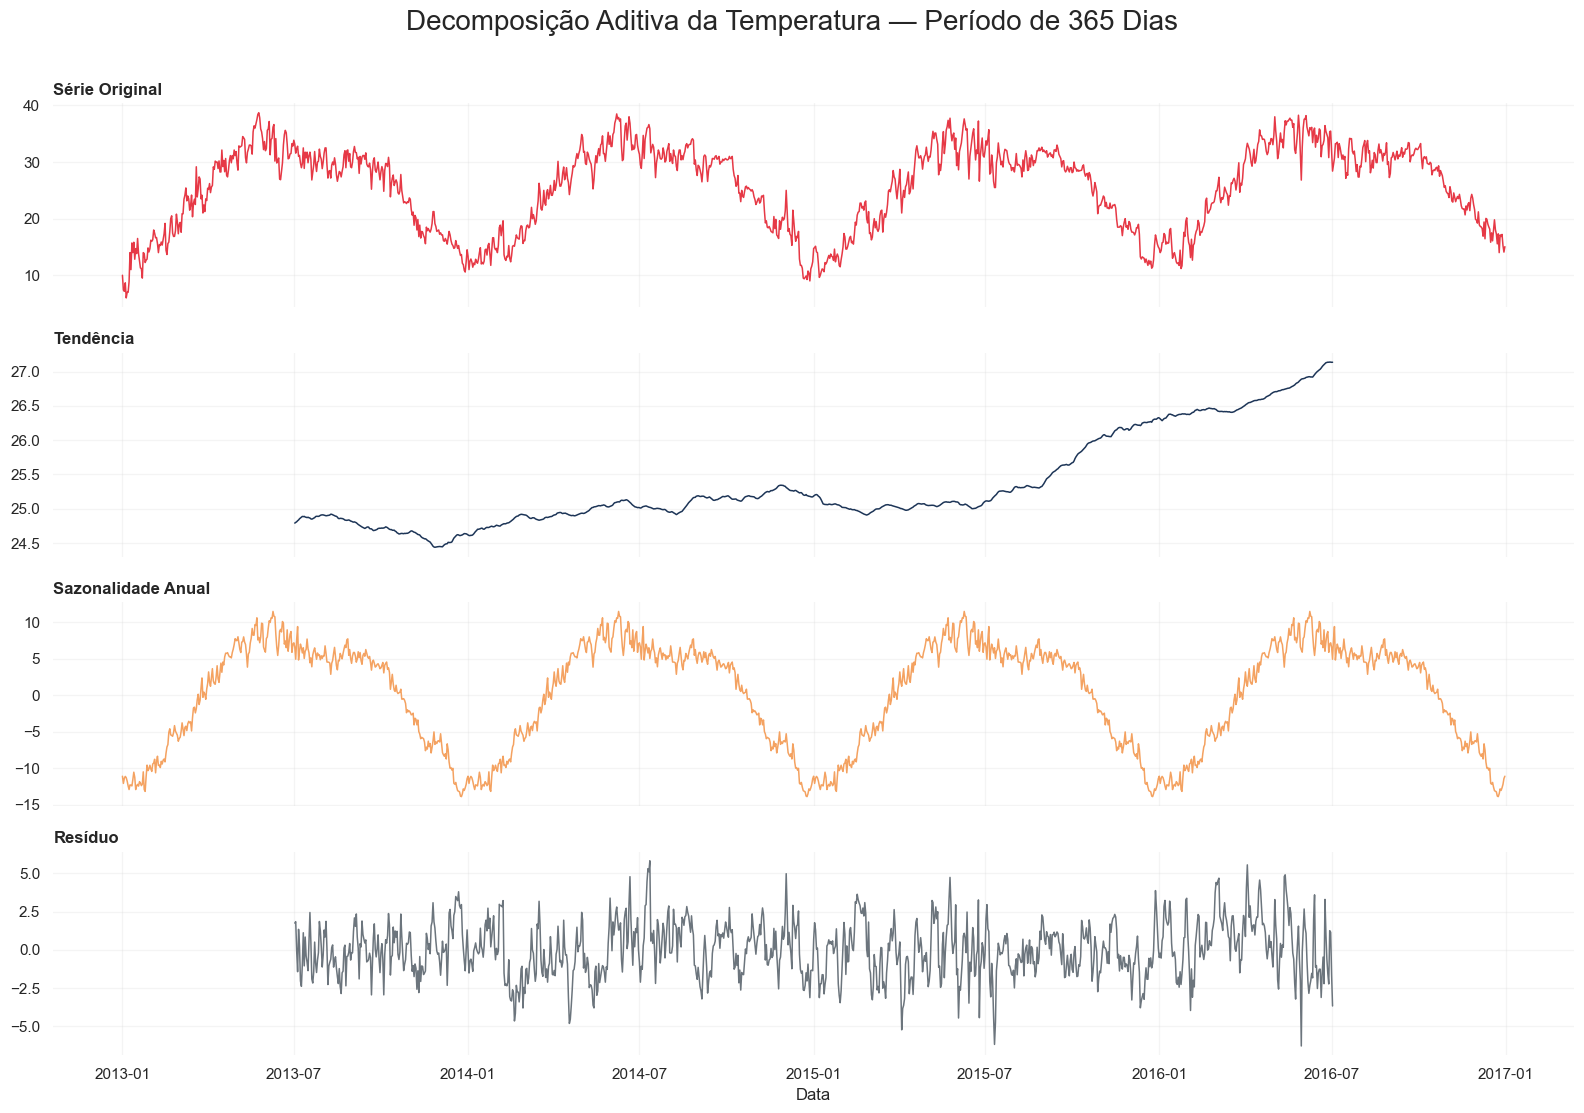

In [8]:
indexed_temp = development.set_index('date')[TARGET].asfreq('D')
decomposition = seasonal_decompose(indexed_temp, model='additive', period=365)

components = [indexed_temp, decomposition.trend, decomposition.seasonal, decomposition.resid]
titles = ['Série Original', 'Tendência', 'Sazonalidade Anual', 'Resíduo']
colors = ['#E63946', '#1D3557', '#F4A261', '#6C757D']

fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
for component, title, color, ax in zip(components, titles, colors, axes):
    ax.plot(component.index, component, color=color, linewidth=1.1)
    ax.set_title(title, loc='left', fontweight='bold')
    ax.grid(alpha=0.20)
    ax.set_frame_on(False)
axes[-1].set_xlabel('Data')
plt.suptitle('Decomposição Aditiva da Temperatura — Período de 365 Dias', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

# <font color='green' style='font-size: 30px;'> 2.4) A série é estacionária? É necessário diferenciar? </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Estacionaridade significa que propriedades como média, variância e autocovariância permanecem aproximadamente estáveis ao longo do tempo. Serão utilizados ADF e KPSS, que possuem hipóteses nulas opostas.
</p>

<center>

| Teste | $H_0$ | Evidência favorável à estacionaridade |
|---|---|---|
| ADF | A série possui raiz unitária | p-valor < 0,05 |
| KPSS | A série é estacionária | p-valor > 0,05 |

</center>

> 1. Os testes serão interpretados em conjunto com os gráficos.
>
> 2. A primeira diferença será comparada com a série em nível e com a diferença anual.
>
> 3. Uma segunda diferença não será aplicada automaticamente, pois diferenciação excessiva pode amplificar ruído e remover estrutura útil para previsão.

C:\Users\leova\AppData\Local\Temp\ipykernel_30108\2874085850.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(values, regression='c', nlags='auto')
C:\Users\leova\AppData\Local\Temp\ipykernel_30108\2874085850.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(values, regression='c', nlags='auto')
C:\Users\leova\AppData\Local\Temp\ipykernel_30108\2874085850.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(values, regression='c', nlags='auto')


,série,ADF p-valor,KPSS p-valor,evidência conjunta de estacionaridade
0,Série em nível,0.2228,0.1000,False
1,Primeira diferença,0.0000,0.1000,True
2,Diferença anual,0.0000,0.0100,False


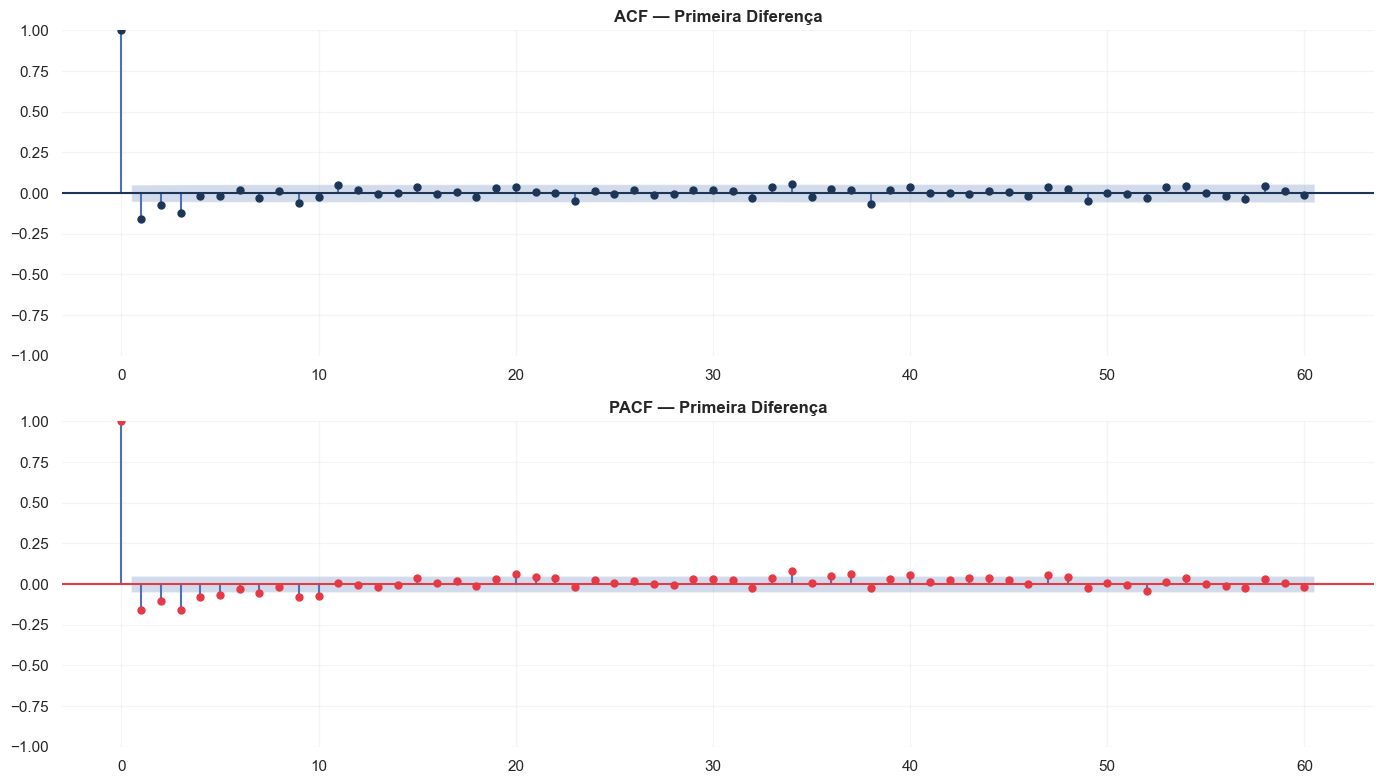

In [9]:
stationarity = pd.DataFrame([
    stationarity_row(indexed_temp, 'Série em nível'),
    stationarity_row(indexed_temp.diff(), 'Primeira diferença'),
    stationarity_row(indexed_temp.diff(365), 'Diferença anual'),
])
display(
    stationarity.style
    .format({'ADF p-valor': '{:.4f}', 'KPSS p-valor': '{:.4f}'})
    .background_gradient(subset=['ADF p-valor'], cmap='RdYlGn_r')
    .background_gradient(subset=['KPSS p-valor'], cmap='RdYlGn')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(indexed_temp.diff().dropna(), lags=60, ax=axes[0], color='#1D3557')
plot_pacf(indexed_temp.diff().dropna(), lags=60, ax=axes[1], method='ywm', color='#E63946')
axes[0].set_title('ACF — Primeira Diferença', fontweight='bold')
axes[1].set_title('PACF — Primeira Diferença', fontweight='bold')
for ax in axes:
    ax.grid(alpha=0.20)
    ax.set_frame_on(False)
plt.tight_layout()
plt.show()

# <font color='green' style='font-size: 30px;'> 2.5) Como a sazonalidade varia ao longo do calendário? </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
A comparação mensal permite observar simultaneamente a temperatura típica de cada mês e sua dispersão. Para os modelos supervisionados, o ciclo anual será representado por seno e cosseno do dia do ano, mantendo dezembro e janeiro próximos no espaço de features.
</p>

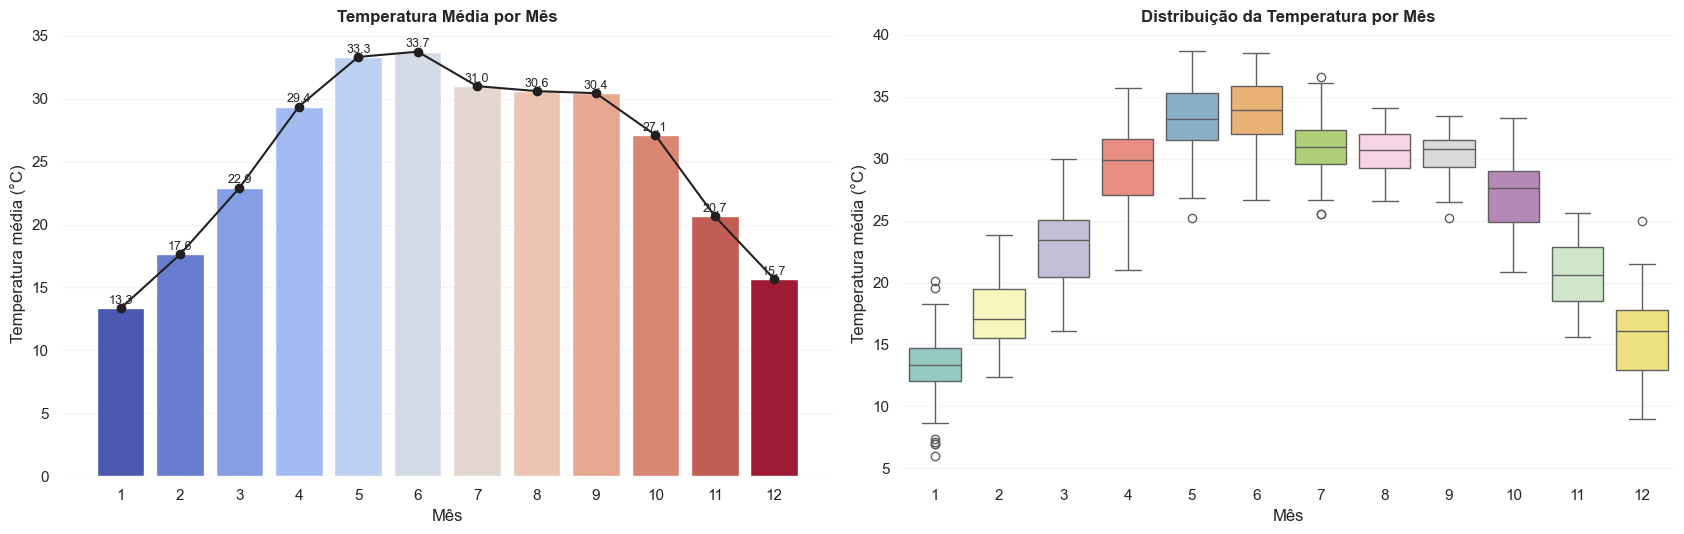

In [10]:
monthly = development.assign(month=development.date.dt.month)
monthly_mean = monthly.groupby('month', as_index=False)[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
sns.barplot(data=monthly_mean, x='month', y=TARGET, hue='month', palette='coolwarm', legend=False, ax=axes[0])
axes[0].plot(monthly_mean['month'] - 1, monthly_mean[TARGET], color='#231F20', marker='o', linewidth=1.5)
axes[0].set_title('Temperatura Média por Mês', fontweight='bold')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Temperatura média (°C)')
for index, value in enumerate(monthly_mean[TARGET]):
    axes[0].text(index, value + 0.35, f'{value:.1f}', ha='center', fontsize=9)

sns.boxplot(data=monthly, x='month', y=TARGET, hue='month', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Distribuição da Temperatura por Mês', fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Temperatura média (°C)')
for ax in axes:
    ax.grid(axis='y', alpha=0.20)
    ax.set_frame_on(False)
plt.tight_layout()
plt.show()

# <font color='green' style='font-size: 30px;'> 2.6) Qual é a intensidade da persistência temporal? </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
A temperatura de dias próximos tende a ser parecida. Essa persistência será investigada por meio da correlação entre a temperatura atual e seus valores defasados.
</p>

> 1. Correlação elevada com lag 1 é esperada fisicamente e não representa, por si só, vazamento.
>
> 2. Correlação não é sinônimo de importância preditiva, principalmente quando vários lags carregam informações semelhantes.
>
> 3. A interpretação das features será complementada por permutação fora do treino e por ablação.

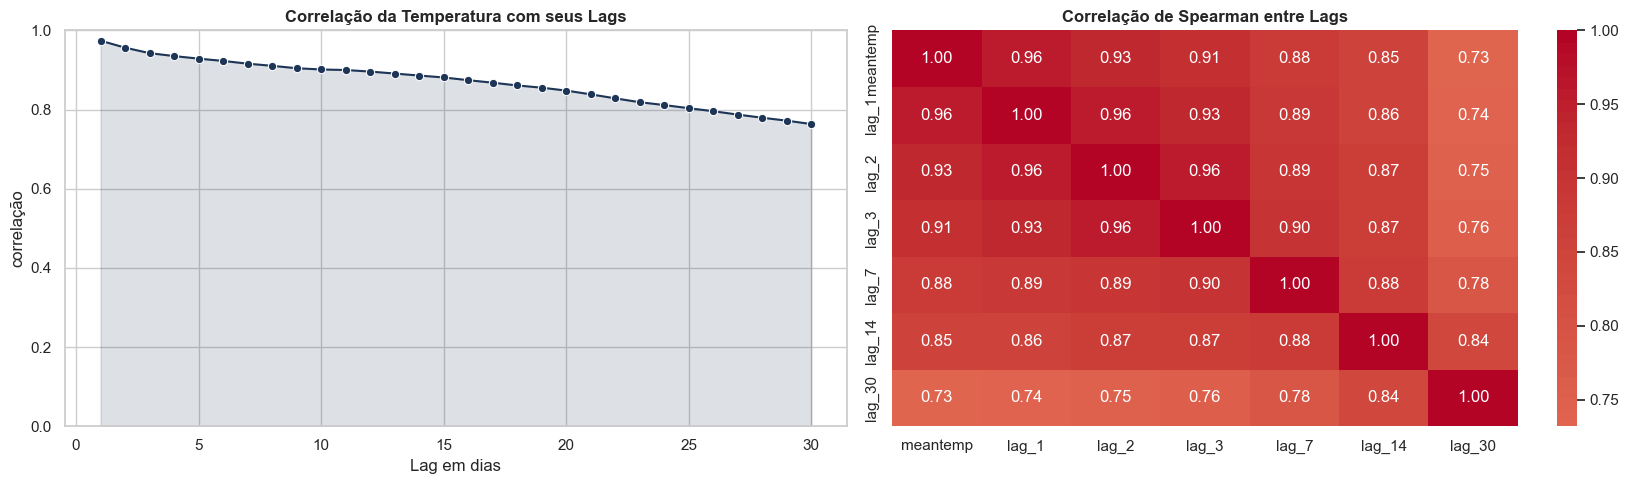

In [11]:
lag_corr = pd.DataFrame({
    'lag': range(1, 31),
    'correlação': [development[TARGET].corr(development[TARGET].shift(lag)) for lag in range(1, 31)],
})

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.lineplot(data=lag_corr, x='lag', y='correlação', marker='o', color='#1D3557', ax=axes[0])
axes[0].fill_between(lag_corr['lag'], lag_corr['correlação'], alpha=0.15, color='#1D3557')
axes[0].set_title('Correlação da Temperatura com seus Lags', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Lag em dias')

lag_matrix = development.assign(**{f'lag_{lag}': development[TARGET].shift(lag) for lag in [1, 2, 3, 7, 14, 30]})
corr = lag_matrix[[TARGET, 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30']].corr(method='spearman')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlação de Spearman entre Lags', fontweight='bold')
plt.tight_layout()
plt.show()

# <font color='red' style='font-size: 40px;'> 3) Amostragem, Pré-Processamento e Feature Engineering </font>
<hr style='border: 2px solid red;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Em séries temporais, as observações não podem ser embaralhadas. A preparação dos dados deve manter a ordem cronológica e reproduzir as informações que estariam disponíveis no momento de cada previsão.
</p>

# <font color='green' style='font-size: 30px;'> 3.1) Amostragem Temporal </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Serão utilizados quatro folds trimestrais de 2016 com janela expansiva. Em cada fold, o treinamento contém todo o histórico anterior e a validação contém o trimestre seguinte.
</p>

| Fold | Validação | Característica climática predominante |
|---|---|---|
| 2016-Q1 | Janeiro a Março | Período mais frio e início do aquecimento |
| 2016-Q2 | Abril a Junho | Período mais quente |
| 2016-Q3 | Julho a Setembro | Monções e resfriamento gradual |
| 2016-Q4 | Outubro a Dezembro | Transição para o período frio |

> Avaliar vários trimestres reduz o risco de escolher um modelo que funciona apenas em uma estação específica.

,fold,treino,validação
0,2016-Q1,até 2015-12-31,2016-01-01 a 2016-03-31
1,2016-Q2,até 2016-03-31,2016-04-01 a 2016-06-30
2,2016-Q3,até 2016-06-30,2016-07-01 a 2016-09-30
3,2016-Q4,até 2016-09-30,2016-10-01 a 2016-12-31


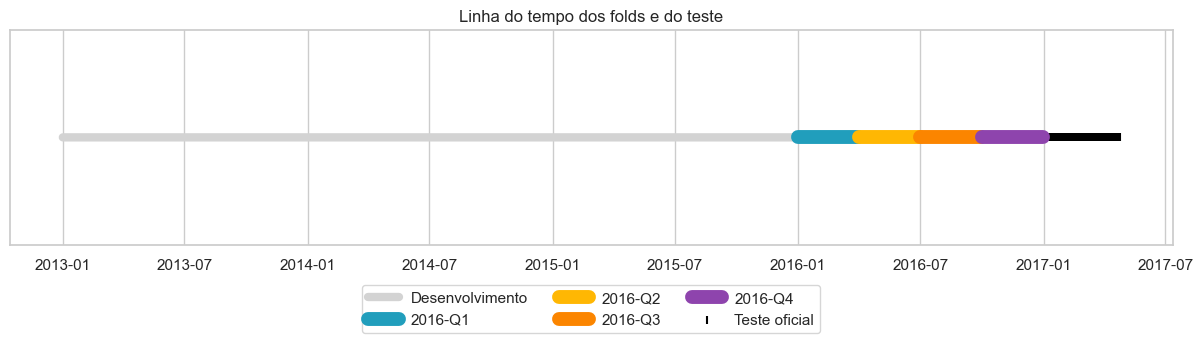

In [12]:
fold_table = []
for fold, start, end in FOLDS:
    fold_table.append({
        'fold': fold,
        'treino': f"até {(pd.Timestamp(start) - pd.Timedelta(days=1)).date()}",
        'validação': f"{start} a {end}",
    })
display(pd.DataFrame(fold_table))

plt.figure(figsize=(15, 2.8))
plt.plot(development.date, np.zeros(len(development)), color='lightgray', linewidth=6, label='Desenvolvimento')
colors = ['#219ebc', '#ffb703', '#fb8500', '#8e44ad']
for (fold, start, end), color in zip(FOLDS, colors):
    dates = development.date.between(start, end)
    plt.plot(development.loc[dates, 'date'], np.zeros(dates.sum()), linewidth=10, label=fold, color=color)
plt.scatter(official_test.date, np.zeros(len(official_test)), marker='|', color='black', label='Teste oficial')
plt.yticks([])
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.title('Linha do tempo dos folds e do teste')
plt.show()

# <font color='green' style='font-size: 30px;'> 3.2) Pré-Processamento e Feature Engineering </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
O benchmark será construído com informações conhecidas antes de D+1. Foram criados lags da temperatura, estatísticas móveis e variáveis de calendário.
</p>

| Grupo | Features |
|---|---|
| Lags | 1, 2, 3, 7, 14 e 30 dias |
| Médias móveis | 3, 7, 14 e 30 dias |
| Desvios móveis | 3, 7, 14 e 30 dias |
| Calendário | seno e cosseno do dia do ano |
| Estrutura de longo prazo | tendência em dias |

> Todas as estatísticas móveis são calculadas depois de `shift(1)`. Consequentemente, nenhuma feature da linha D+1 contém a própria temperatura de D+1.

In [13]:
model_data = make_features(development, official_test)
print(f'{len(FEATURES)} features; primeira data utilizável: {model_data.date.min().date()}')
display(model_data[['date', TARGET] + FEATURES].head().round(3))

# Verificação explícita da causalidade do lag 1 em uma linha arbitrária.
sample_index = 100
assert model_data.loc[sample_index, 'temp_lag_1'] == model_data.loc[sample_index - 1, TARGET]
print('Verificação causal aprovada: lag 1 da linha t = temperatura observada em t-1.')

17 features; primeira data utilizável: 2013-01-31


,date,meantemp,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_7,temp_lag_14,temp_lag_30,temp_roll_mean_3,temp_roll_std_3,temp_roll_mean_7,temp_roll_std_7,temp_roll_mean_14,temp_roll_std_14,temp_roll_mean_30,temp_roll_std_30,doy_sin,doy_cos,trend_days
0,2013-01-31,16.200,14.714,14.125,14.833,13.833,16.500,10.000,14.558,0.379,13.611,1.028,13.150,1.782,11.937,3.018,0.508,0.861,30
1,2013-02-01,16.000,16.200,14.714,14.125,12.250,13.833,7.400,15.013,1.069,13.949,1.425,13.128,1.739,12.144,3.092,0.523,0.852,31
2,2013-02-02,16.286,16.000,16.200,14.714,12.667,12.500,7.167,15.638,0.806,14.485,1.384,13.283,1.896,12.431,3.035,0.538,0.843,32
3,2013-02-03,18.000,16.286,16.000,16.200,12.857,11.286,8.667,16.162,0.147,15.002,1.262,13.554,2.040,12.735,2.945,0.552,0.834,33
4,2013-02-04,17.429,18.000,16.286,16.000,14.833,11.200,6.000,16.762,1.082,15.737,1.302,14.033,2.245,13.046,2.993,0.566,0.824,34


Verificação causal aprovada: lag 1 da linha t = temperatura observada em t-1.


# <font color='red' style='font-size: 40px;'> 4) Modelagem </font>
<hr style='border: 2px solid red;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Todos os modelos serão avaliados como previsores D+1 walk-forward. Após prever um dia, o valor realizado é incorporado ao histórico antes da previsão seguinte. Assim, ARIMA, SARIMA, Random Forest, LightGBM e LSTM resolvem exatamente a mesma tarefa.
</p>

### Modelos avaliados

> 1. Persistência D-1 e Sazonal Ingênuo D-7
>
> 2. ARIMA
>
> 3. SARIMA
>
> 4. Random Forest
>
> 5. LightGBM
>
> 6. LSTM

### Métricas

| Métrica | Objetivo |
|---|---|
| MAE | Erro absoluto médio em °C — métrica principal |
| RMSE | Penalizar erros grandes com maior intensidade |
| MASE | Comparar o erro com a escala ingênua do treino |
| sMAPE | Medir erro percentual de forma simétrica |

# <font color='green' style='font-size: 30px;'> 4.1) Modelos Estatísticos — ARIMA e SARIMA </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
O ARIMA combina três componentes: autorregressão AR(p), diferenciação I(d) e média móvel MA(q). Um conjunto pequeno de ordens parcimoniosas será comparado por AIC utilizando somente dados anteriores a 2016.
</p>

| Modelo | ACF | PACF |
|---|---|---|
| AR(p) | Decai gradualmente | Pode apresentar corte após p |
| MA(q) | Pode apresentar corte após q | Decai gradualmente |
| ARMA(p,q) | Decai gradualmente | Decai gradualmente |

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
O SARIMA acrescenta uma componente sazonal semanal de período 7. O ciclo anual é evidente, mas um período sazonal 365 exigiria uma estrutura pouco parcimoniosa para aproximadamente quatro anos de histórico. Depois do ajuste, os parâmetros permanecem fixos dentro do fold e o estado do modelo é atualizado a cada observação realizada.
</p>

In [14]:
experiment = run_experiment('data')

print(f'Ordem ARIMA escolhida antes da validação: {experiment.arima_order}')
print(f'Ordens SARIMA: {experiment.sarima_order} x {experiment.seasonal_order}')
display(
    experiment.cv_summary[experiment.cv_summary.model.isin(['ARIMA', 'SARIMA'])]
    .round(3)
)

Ordem ARIMA escolhida antes da validação: (1, 1, 1)
Ordens SARIMA: (1, 1, 1) x (0, 0, 1, 7)


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MASE_mean,MASE_std,sMAPE_%_mean,sMAPE_%_std
3,SARIMA,1.268,0.175,1.623,0.235,1.03,0.149,5.114,1.536
4,ARIMA,1.366,0.174,2.110,0.373,1.11,0.146,5.505,0.839


# <font color='green' style='font-size: 30px;'> 4.2) Modelos de Machine Learning — Random Forest e LightGBM </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Random Forest e LightGBM conseguem representar interações não lineares entre lags, médias móveis e calendário. Para controlar a variância, foram limitadas a profundidade, o tamanho mínimo das folhas e a quantidade de folhas.
</p>

> 1. A importância será calculada por permutação no quarto fold, que não participou do treinamento daquele modelo.
>
> 2. Como os lags são correlacionados, a importância individual será complementada por uma ablação.
>
> 3. Serão comparadas três versões: todas as features, sem lag 1 e somente lag 1.

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MASE_mean,MASE_std,sMAPE_%_mean,sMAPE_%_std
1,Random Forest,1.259,0.311,1.592,0.346,1.024,0.260,4.965,1.260
2,LightGBM,1.267,0.295,1.619,0.356,1.030,0.246,5.003,1.202


,model,features,MAE,RMSE,MASE,sMAPE_%
0,LightGBM,todas,0.964,1.183,0.778,4.534
1,LightGBM,sem lag 1,0.974,1.208,0.786,4.536
2,LightGBM,somente lag 1,1.059,1.348,0.854,4.974
3,Random Forest,todas,0.922,1.177,0.744,4.370
4,Random Forest,sem lag 1,0.965,1.241,0.779,4.519
5,Random Forest,somente lag 1,1.074,1.356,0.866,5.039


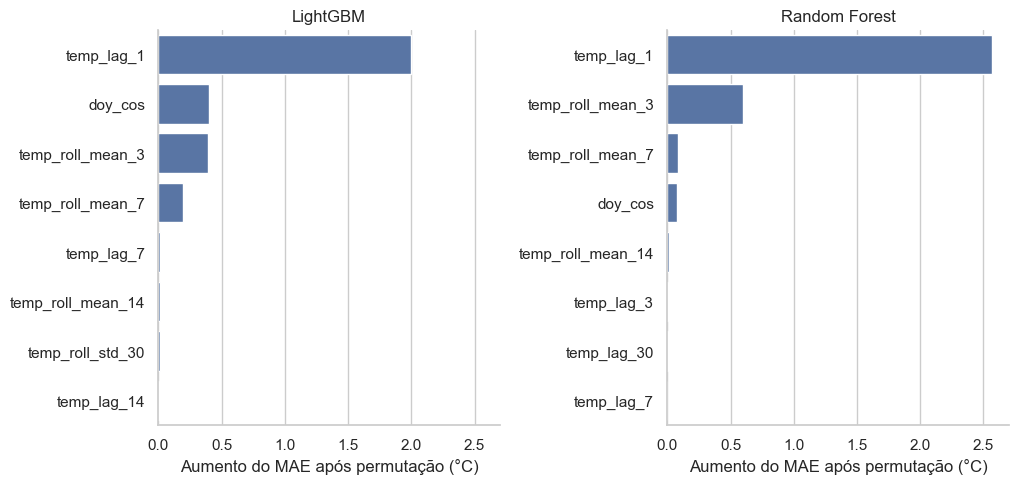

In [15]:
display(
    experiment.cv_summary[experiment.cv_summary.model.isin(['Random Forest', 'LightGBM'])]
    .round(3)
)
display(experiment.ablation.round(3))

top_importance = (
    experiment.importance.groupby('model', group_keys=False)
    .head(8)
    .copy()
)
g = sns.catplot(
    data=top_importance, x='MAE_increase', y='feature', col='model',
    kind='bar', sharey=False, height=5, aspect=1.05,
)
g.set_axis_labels('Aumento do MAE após permutação (°C)', '')
g.set_titles('{col_name}')
plt.show()

# <font color='green' style='font-size: 30px;'> 4.3) Modelo de Deep Learning — LSTM </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
LSTM é uma Rede Neural Recorrente capaz de processar sequências. Seu mecanismo de portas controla quais informações devem ser esquecidas, armazenadas e propagadas, reduzindo o problema de desaparecimento do gradiente em dependências mais longas.
</p>

### Estrutura utilizada

- Janela de entrada com as 30 temperaturas anteriores;
- Uma camada LSTM com 32 unidades;
- Dropout de 20%;
- Uma saída linear para a temperatura D+1;
- Otimizador Adam e função de perda MSE.

### Treinamento temporal

> 1. Os 15% finais de cada treino formam uma validação interna.
>
> 2. O early stopping escolhe o número de épocas sem acessar o fold externo.
>
> 3. A rede é reinicializada e treinada em todo o treino pelo número de épocas selecionado.
>
> 4. As janelas atravessam a fronteira do fold, pois o histórico anterior continua disponível para prever o primeiro dia da validação.

In [16]:
lstm_folds = experiment.cv_detail.loc[
    experiment.cv_detail.model == 'LSTM',
    ['fold', 'best_epoch', 'MAE', 'RMSE', 'MASE', 'sMAPE_%'],
]
display(lstm_folds.round(3))
display(experiment.cv_summary[experiment.cv_summary.model == 'LSTM'].round(3))

,fold,best_epoch,MAE,RMSE,MASE,sMAPE_%
6,2016-Q1,18.0,1.946,2.428,1.588,10.438
13,2016-Q2,60.0,1.914,2.359,1.566,5.711
20,2016-Q3,59.0,1.486,1.933,1.199,4.778
27,2016-Q4,55.0,1.053,1.327,0.849,4.917


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MASE_mean,MASE_std,sMAPE_%_mean,sMAPE_%_std
5,LSTM,1.599,0.42,2.012,0.506,1.3,0.35,6.461,2.683


# <font color='green' style='font-size: 30px;'> 4.4) Benchmark Consolidado </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
O ranking principal será determinado pelo MAE médio dos quatro folds. O desvio-padrão mostra quanto o desempenho varia entre os trimestres. Somente depois de observar a validação, os modelos serão ajustados no desenvolvimento completo e avaliados no teste oficial.
</p>

> O teste não será utilizado para escolher o vencedor. Se um modelo liderar apenas no teste, essa informação será tratada como resultado final, não como novo critério de seleção.

Validação temporal — quatro folds trimestrais de 2016


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MASE_mean,MASE_std,sMAPE_%_mean,sMAPE_%_std
0,Persistência D-1,1.227,0.183,1.625,0.254,0.996,0.154,4.925,1.072
1,Random Forest,1.259,0.311,1.592,0.346,1.024,0.260,4.965,1.260
2,LightGBM,1.267,0.295,1.619,0.356,1.030,0.246,5.003,1.202
3,SARIMA,1.268,0.175,1.623,0.235,1.030,0.149,5.114,1.536
4,ARIMA,1.366,0.174,2.110,0.373,1.110,0.146,5.505,0.839
5,LSTM,1.599,0.420,2.012,0.506,1.300,0.350,6.461,2.683
6,Sazonal ingênuo D-7,2.275,0.344,2.824,0.487,1.849,0.288,9.162,2.927


Teste oficial — aberto somente após o protocolo estar definido


,model,MAE,RMSE,MASE,sMAPE_%,skill_vs_persistence_%,best_epoch
0,Random Forest,1.300,1.647,1.061,6.495,1.011,nan
1,Persistência D-1,1.314,1.684,1.072,6.615,0.000,nan
2,ARIMA,1.335,1.681,1.089,6.624,-1.589,nan
3,LightGBM,1.355,1.686,1.106,6.786,-3.184,nan
4,SARIMA,1.512,1.893,1.234,7.251,-15.069,nan
5,LSTM,1.743,2.118,1.422,8.830,-32.655,60.000
6,Sazonal ingênuo D-7,2.978,3.663,2.430,14.681,-126.664,nan


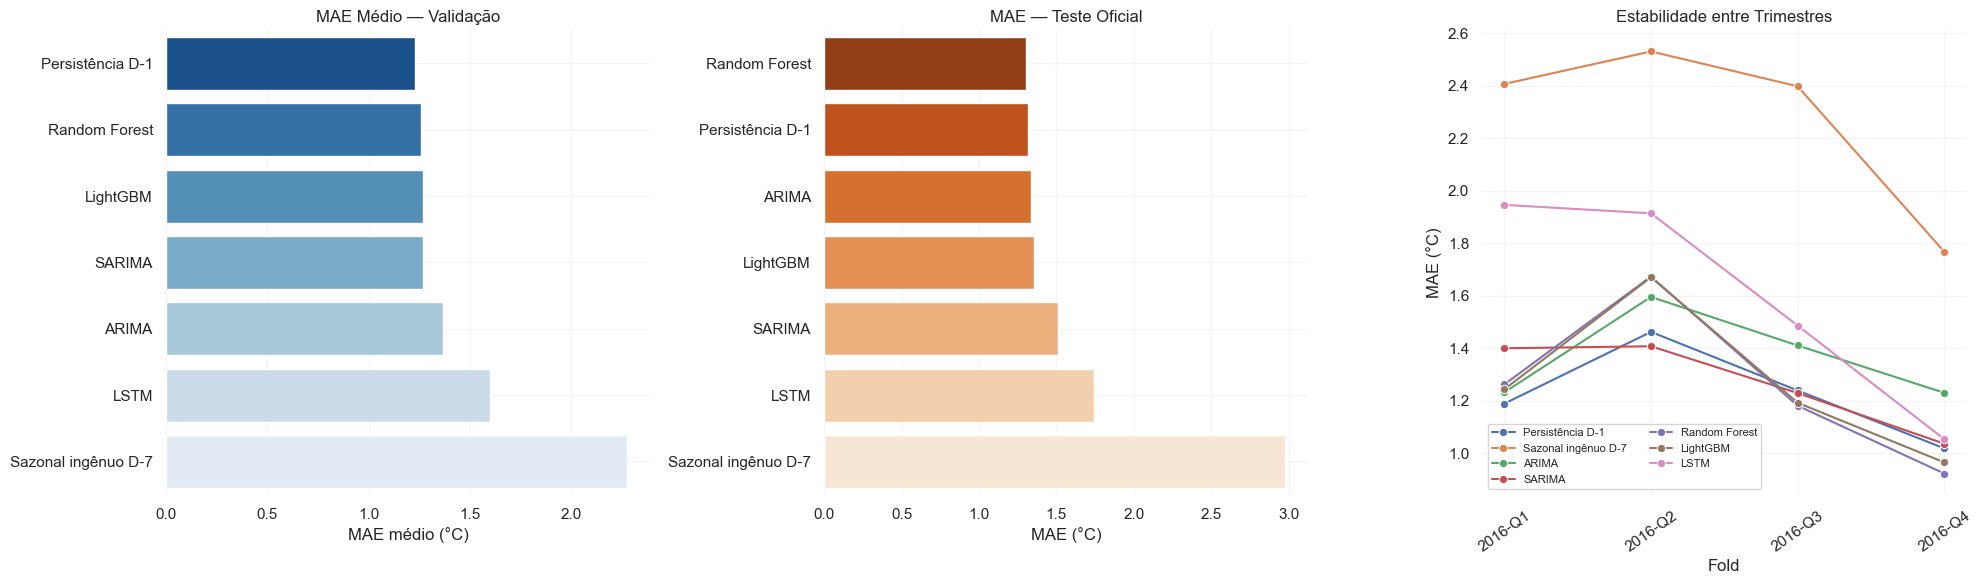

In [17]:
print('Validação temporal — quatro folds trimestrais de 2016')
display(
    experiment.cv_summary.style
    .format(precision=3)
    .background_gradient(subset=['MAE_mean', 'RMSE_mean'], cmap='RdYlGn_r')
)

print('Teste oficial — aberto somente após o protocolo estar definido')
display(
    experiment.test_metrics.style
    .format(precision=3)
    .background_gradient(subset=['MAE', 'RMSE'], cmap='RdYlGn_r')
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cv_plot = experiment.cv_summary.sort_values('MAE_mean')
sns.barplot(data=cv_plot, x='MAE_mean', y='model', hue='model', palette='Blues_r', legend=False, ax=axes[0])
axes[0].set(title='MAE Médio — Validação', xlabel='MAE médio (°C)', ylabel='')

test_plot = experiment.test_metrics.sort_values('MAE')
sns.barplot(data=test_plot, x='MAE', y='model', hue='model', palette='Oranges_r', legend=False, ax=axes[1])
axes[1].set(title='MAE — Teste Oficial', xlabel='MAE (°C)', ylabel='')

fold_plot = experiment.cv_detail.copy()
sns.lineplot(data=fold_plot, x='fold', y='MAE', hue='model', marker='o', ax=axes[2])
axes[2].set(title='Estabilidade entre Trimestres', xlabel='Fold', ylabel='MAE (°C)')
axes[2].tick_params(axis='x', rotation=35)
axes[2].legend(fontsize=8, ncol=2)

for ax in axes:
    ax.grid(alpha=0.20)
    ax.set_frame_on(False)
plt.tight_layout()
plt.show()

# <font color='green' style='font-size: 30px;'> 4.5) Previsões, Resíduos e Incerteza da Comparação </font>
<hr style='border: 2px solid green;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Além das métricas agregadas, serão comparadas as trajetórias previstas e os resíduos. O teste de Ljung–Box avalia se ainda existe autocorrelação nos erros em até sete dias.
</p>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
Uma pequena diferença de MAE pode ser consequência das datas específicas do teste. Por isso, será utilizado bootstrap em blocos de sete dias. Um modelo só será considerado robustamente superior à persistência quando todo o intervalo de 95% do ganho permanecer acima de zero.
</p>

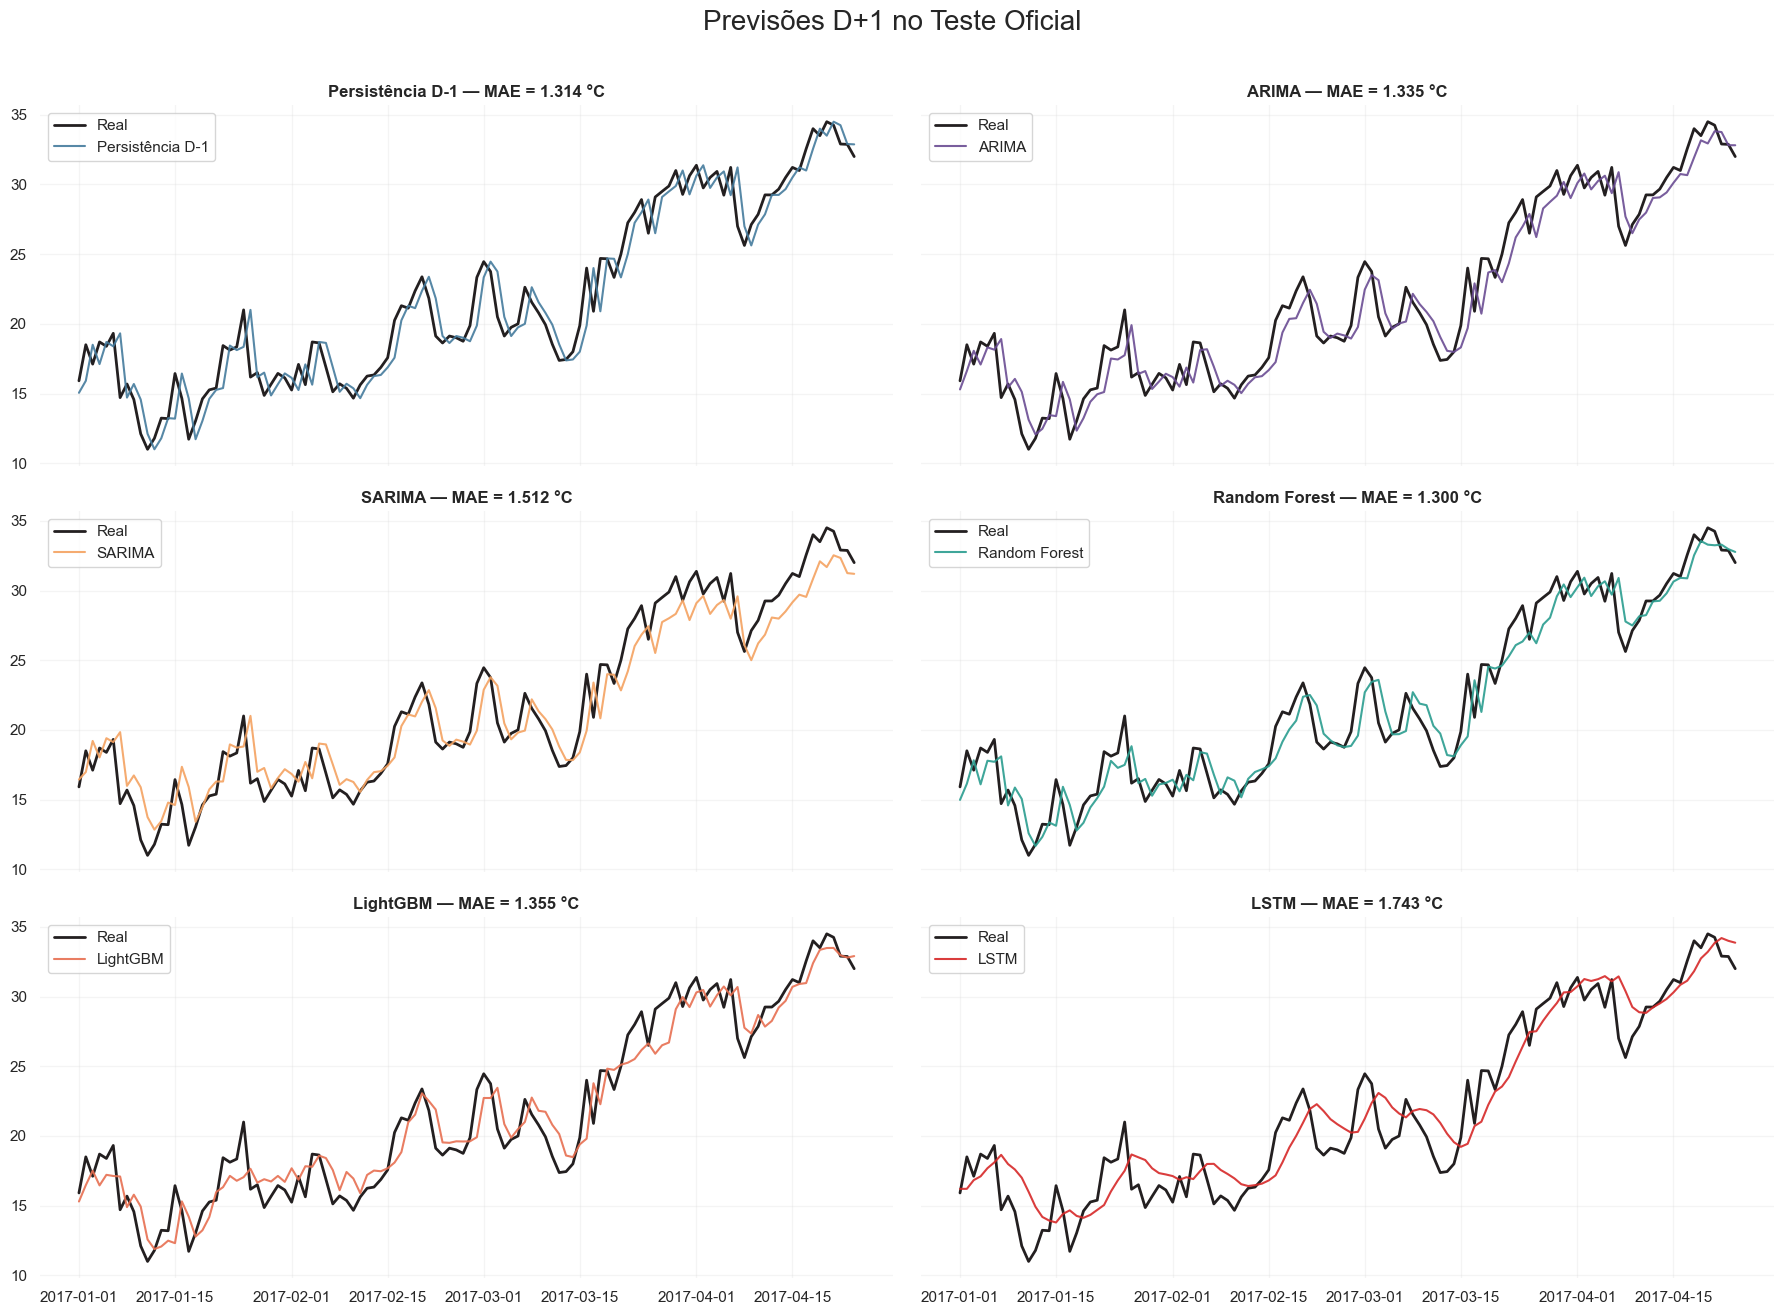

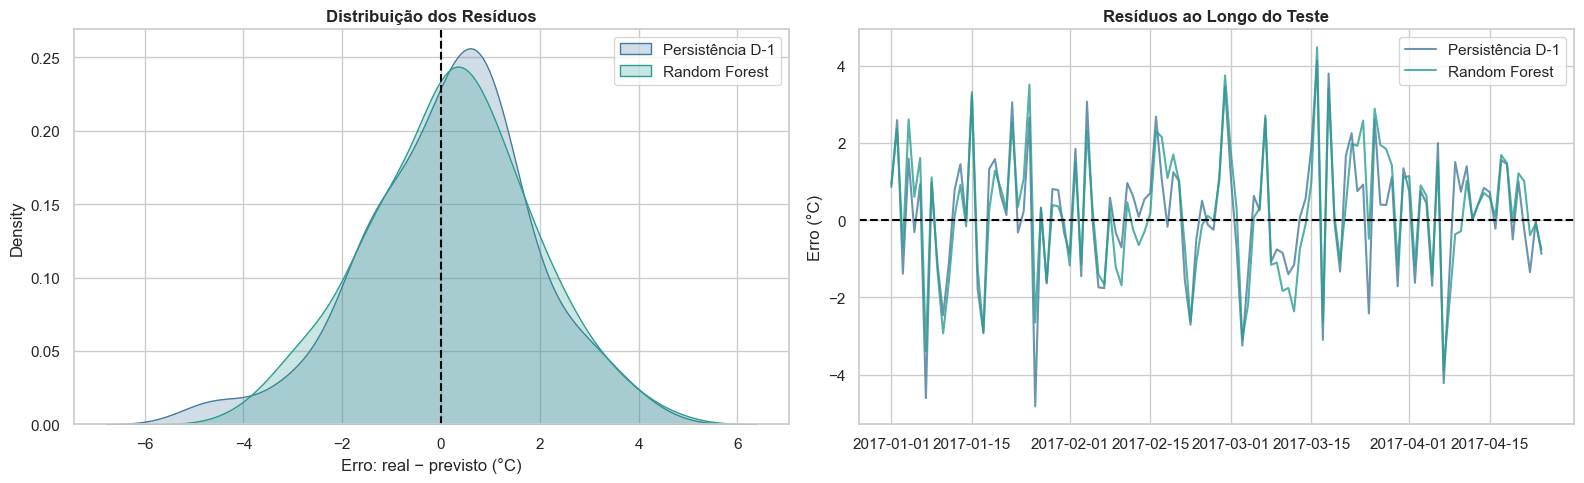

,modelo,ganho médio de MAE (°C),IC 95% inferior,IC 95% superior,ganho robusto?
3,Random Forest,0.013,-0.096,0.112,False
1,ARIMA,-0.021,-0.118,0.069,False
4,LightGBM,-0.042,-0.200,0.098,False
2,SARIMA,-0.198,-0.415,-0.013,False
5,LSTM,-0.429,-0.674,-0.195,False
0,Sazonal ingênuo D-7,-1.664,-2.244,-1.096,False


,modelo,Q(7),p-valor
1,Sazonal ingênuo D-7,138.207,0.0000
6,LSTM,69.235,0.0000
3,SARIMA,56.947,0.0000
5,LightGBM,15.283,0.0325
4,Random Forest,7.088,0.4198
0,Persistência D-1,6.044,0.5346
2,ARIMA,5.798,0.5635


In [18]:
pred = experiment.test_predictions
models_to_plot = ['Persistência D-1', 'ARIMA', 'SARIMA', 'Random Forest', 'LightGBM', 'LSTM']
colors = ['#457B9D', '#6A4C93', '#F4A261', '#2A9D8F', '#E76F51', '#D62828']

fig, axes = plt.subplots(3, 2, figsize=(18, 13), sharex=True, sharey=True)
for model, color, ax in zip(models_to_plot, colors, axes.ravel()):
    ax.plot(pred.date, pred[TARGET], label='Real', color='#231F20', linewidth=2)
    ax.plot(pred.date, pred[model], label=model, color=color, linewidth=1.5, alpha=0.9)
    mae = np.mean(np.abs(pred[TARGET] - pred[model]))
    ax.set_title(f'{model} — MAE = {mae:.3f} °C', fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.20)
    ax.set_frame_on(False)
plt.suptitle('Previsões D+1 no Teste Oficial', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for model, color in [('Persistência D-1', '#457B9D'), ('Random Forest', '#2A9D8F')]:
    residual = pred[TARGET] - pred[model]
    sns.kdeplot(residual, fill=True, alpha=0.25, label=model, color=color, ax=axes[0])
    axes[1].plot(pred.date, residual, label=model, color=color, alpha=0.8)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[0].set_xlabel('Erro: real − previsto (°C)')
axes[0].legend()
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Resíduos ao Longo do Teste', fontweight='bold')
axes[1].set_ylabel('Erro (°C)')
axes[1].legend()
plt.tight_layout()
plt.show()

bootstrap = block_bootstrap_comparison(pred)
display(
    bootstrap.style
    .format(precision=3)
    .background_gradient(subset=['ganho médio de MAE (°C)'], cmap='RdYlGn')
)

ljung_rows = []
for model in [c for c in pred.columns if c not in {'date', TARGET}]:
    residual = pred[TARGET] - pred[model]
    test = acorr_ljungbox(residual, lags=[7], return_df=True).iloc[0]
    ljung_rows.append({'modelo': model, 'Q(7)': test.lb_stat, 'p-valor': test.lb_pvalue})
ljung_result = pd.DataFrame(ljung_rows).sort_values('p-valor')
display(ljung_result.style.format({'Q(7)': '{:.3f}', 'p-valor': '{:.4f}'}))

# <font color='red' style='font-size: 40px;'> 5) Conclusões </font>
<hr style='border: 2px solid red;'>

<p style='font-size: 18px; line-height: 2; text-align: justify;'>
O experimento mostrou que a previsão D+1 de temperatura possui um baseline particularmente forte. Na validação temporal, a Persistência D-1 obteve o menor MAE médio, aproximadamente 1,227 °C. Random Forest, LightGBM e SARIMA ficaram próximos, enquanto ARIMA e LSTM apresentaram erros maiores.
</p>

### 5.1) O modelo mais complexo foi necessariamente melhor?

> Não. A LSTM obteve MAE médio de aproximadamente 1,599 °C e não conseguiu transformar sua capacidade de representação em melhor generalização. O tamanho da série e a forte persistência favorecem modelos mais simples.

### 5.2) A Random Forest venceu no teste?

> A Random Forest apresentou MAE aproximadamente 0,013 °C menor do que a persistência, uma melhora próxima de 1%. Entretanto, o intervalo bootstrap de 95% ficou aproximadamente entre −0,096 °C e 0,112 °C. Como o intervalo contém zero, a vantagem não é robusta.

### 5.3) O lag 1 representa 100% da previsão?

> O lag 1 é importante porque a temperatura diária muda gradualmente. Porém, ao removê-lo, lags próximos e médias móveis conseguem recuperar parte da informação. A concentração observada em uma única importância não deve ser interpretada como exclusividade causal.

### 5.4) Decisão Final

<div style='background-color:#e8f5e9; border-left:7px solid #2e7d32; padding:16px; font-size:18px; line-height:1.8;'>
Para previsão de temperatura D+1 sem previsões meteorológicas externas, a <b>Persistência D-1</b> é o benchmark operacional recomendado. Random Forest, LightGBM e SARIMA permanecem como candidatos de pesquisa, mas não demonstraram ganho estável suficiente para justificar maior complexidade.
</div>

<p style='font-size: 18px; line-height: 2; text-align: justify; margin-top:15px;'>
Essa conclusão é específica para D+1. Previsões D+7 ou D+30 exigiriam um novo experimento, com features deslocadas pelo horizonte e avaliação direta ou recursiva sem utilizar valores realizados dentro do período previsto.
</p>